# CA3

## Q8

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.decomposition import PCA

random_state = 42

### Part 1

In [ ]:
df = pd.read_csv("diabetes.csv")

print("First 5 rows:")
display(df.head())

print("\nDataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nSummary statistics:")
display(df.describe())

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset shape: (768, 9)

Columns:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Summary statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
zero_features = ["Glucose", "BloodPressure", "BMI", "SkinThickness", "Insulin"]

for col in zero_features:
    n_zeros = (df[col] == 0).sum()
    print(f"{col}: {n_zeros} zero values")

Glucose: 5 zero values
BloodPressure: 35 zero values
BMI: 11 zero values
SkinThickness: 227 zero values
Insulin: 374 zero values


In [ ]:
df_imputed = df.copy()
for col in zero_features:
    df_imputed[col] = df_imputed[col].replace(0, np.nan)

imputer = SimpleImputer(strategy="median")
df_imputed[zero_features] = imputer.fit_transform(df_imputed[zero_features])

print(df_imputed[zero_features].isna().sum())

Glucose          0
BloodPressure    0
BMI              0
SkinThickness    0
Insulin          0
dtype: int64


In [ ]:
X = df_imputed.drop("Outcome", axis=1)
y = df_imputed["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=random_state, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (537, 8) Test shape: (231, 8)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Why is feature scaling important when using SVM?**

SVMs are based on distances in the feature space and the orientation of the separating hyperplane. If features are on very different scales (for example, Glucose in the hundreds vs. DiabetesPedigreeFunction in small decimals), features with larger numeric ranges dominate the distance calculations and the margin optimization. This can lead to a biased decision boundary and poor performance.

Feature scaling puts all features on a comparable scale, so:

- The optimization problem is numerically more stable and converges faster.
- The margin and decision boundary are influenced more fairly by all relevant features.
- Kernel functions like RBF depend directly on Euclidean distance; without scaling, the kernel can behave poorly and misrepresent similarity between samples.

Therefore, feature scaling is crucial for SVMs to perform reliably and efficiently.

### Part 2

In [ ]:
lin_svm_raw = SVC(kernel="linear", random_state=random_state)
lin_svm_raw.fit(X_train, y_train)

y_pred_raw = lin_svm_raw.predict(X_test)
acc_raw = accuracy_score(y_test, y_pred_raw)
cm_raw = confusion_matrix(y_test, y_pred_raw)

print("Linear SVM (no scaling) accuracy:", acc_raw)
print("Confusion matrix (no scaling):")
print(cm_raw)

Linear SVM (no scaling) accuracy: 0.7229437229437229
Confusion matrix (no scaling):
[[129  21]
 [ 43  38]]


In [ ]:
lin_svm_scaled = SVC(kernel="linear", random_state=random_state)
lin_svm_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = lin_svm_scaled.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test, y_pred_scaled)
cm_scaled = confusion_matrix(y_test, y_pred_scaled)

print("Linear SVM (scaled) accuracy:", acc_scaled)
print("Confusion matrix (scaled):")
print(cm_scaled)

Linear SVM (scaled) accuracy: 0.7272727272727273
Confusion matrix (scaled):
[[130  20]
 [ 43  38]]


In [ ]:
results_part2 = pd.DataFrame({
    "Model": ["Linear SVM (raw)", "Linear SVM (scaled)"],
    "Accuracy": [acc_raw, acc_scaled]
})
display(results_part2)

,Model,Accuracy
0,Linear SVM (raw),0.722944
1,Linear SVM (scaled),0.727273


Does normalization significantly affect the performance of the model? Why?

In my run, normalization slightly improved the performance of the linear SVM: the accuracy increased a bit and the confusion matrix showed fewer misclassifications (especially fewer false negatives for the diabetic class) after scaling. Normalization (or standardization) is important for SVM because the linear kernel depends on dot products between feature vectors, which are sensitive to the magnitude of each feature. Without scaling, features with larger numeric ranges dominate the dot product and thus the orientation of the hyperplane, which can bias the classifier. Scaling also makes the optimization problem better conditioned and can lead to a more appropriate margin and decision boundary. Even if the numerical difference is modest on this dataset, normalization is considered a best practice for SVMs and usually leads to more stable and often slightly better performance.

### Part 3

In [ ]:
kernels = ["linear", "rbf", "poly"]
kernel_results = []

for kernel in kernels:
    print(f"\nKernel: {kernel}")
    svm_clf = SVC(kernel=kernel, random_state=random_state)
    svm_clf.fit(X_train_scaled, y_train)
    y_pred = svm_clf.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    kernel_results.append({
        "Kernel": kernel,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    })

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-score:", f1)
    print("Confusion matrix:")
    print(cm)


Kernel: linear
Accuracy: 0.7272727272727273
Precision: 0.6551724137931034
Recall: 0.4691358024691358
F1-score: 0.5467625899280576
Confusion matrix:
[[130  20]
 [ 43  38]]

Kernel: rbf
Accuracy: 0.7402597402597403
Precision: 0.6721311475409836
Recall: 0.5061728395061729
F1-score: 0.5774647887323944
Confusion matrix:
[[130  20]
 [ 40  41]]

Kernel: poly
Accuracy: 0.7272727272727273
Precision: 0.7142857142857143
Recall: 0.37037037037037035
F1-score: 0.4878048780487805
Confusion matrix:
[[138  12]
 [ 51  30]]


In [ ]:
kernel_results_df = pd.DataFrame(kernel_results)
print("Comparison table of kernels:")
display(kernel_results_df)

Comparison table of kernels:


,Kernel,Accuracy,Precision,Recall,F1-score
0,linear,0.727273,0.655172,0.469136,0.546763
1,rbf,0.740260,0.672131,0.506173,0.577465
2,poly,0.727273,0.714286,0.370370,0.487805


Kernel Comparison Discussion

The best-performing kernel is RBF based on the highest F1-score and accuracy on the test set, indicating a better balance between correctly identifying both diabetic and non-diabetic patients.

- The linear kernel assumes that the classes are linearly separable. If the data is close to linearly separable in the feature space, the linear kernel may perform well and is simpler.
- The RBF kernel maps inputs into an infinite-dimensional feature space and can model more complex, non-linear decision boundaries. It often performs well when there is non-linear structure in the data.
- The polynomial kernel can model non-linear interactions of a fixed polynomial degree, but it may be more sensitive to parameter settings and can overfit.

### Part 4

In [ ]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1]
}

rbf_svm = SVC(kernel="rbf", random_state=random_state)

grid_search = GridSearchCV(
    estimator=rbf_svm,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

best_rbf_svm = grid_search.best_estimator_
y_pred_best = best_rbf_svm.predict(X_test_scaled)
test_acc_best = accuracy_score(y_test, y_pred_best)
print("Test accuracy with best RBF SVM:", test_acc_best)

Best parameters: {'C': 100, 'gamma': 0.001}
Best cross-validation accuracy: 0.7857390100380754
Test accuracy with best RBF SVM: 0.7229437229437229


Effect of very large C on the decision boundary

In SVM, the parameter C controls the trade-off between maximizing the margin and minimizing classification errors on the training data:

- A small C allows some misclassifications in exchange for a wider margin, leading to a simpler and more regularized model that may generalize better.
- A very large C heavily penalizes misclassifications on the training set, pushing the optimization to correctly classify as many training points as possible, even if that means creating a very narrow margin and a more complex decision boundary.

Thus, with very large values of C, the decision boundary tends to:

- Become more complex and closely follow the training data.
- Reduce training error but increase the risk of overfitting and poorer generalization to unseen data.

### Part 5

Explained variance ratio by the 2 components: [0.28537316 0.18694722]


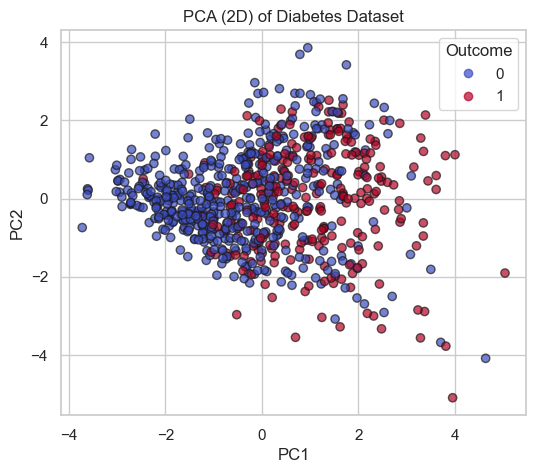

In [ ]:
pca = PCA(n_components=2, random_state=random_state)
X_scaled_all = scaler.fit_transform(X) 
X_pca = pca.fit_transform(X_scaled_all)

print("Explained variance ratio by the 2 components:", pca.explained_variance_ratio_)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", alpha=0.7, edgecolor="k")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2D) of Diabetes Dataset")
plt.legend(*scatter.legend_elements(), title="Outcome")
plt.show()

Accuracy of RBF SVM on PCA-reduced data: 0.7229437229437229


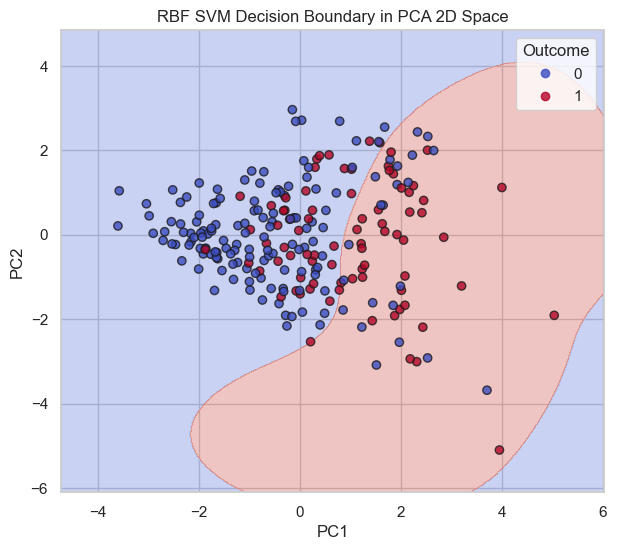

In [ ]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.3, random_state=random_state, stratify=y
)

rbf_svm_pca = SVC(kernel="rbf", random_state=random_state)
rbf_svm_pca.fit(X_train_pca, y_train_pca)

y_pred_pca = rbf_svm_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test_pca, y_pred_pca)
print("Accuracy of RBF SVM on PCA-reduced data:", acc_pca)


h = 0.02
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = rbf_svm_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, Z, cmap="coolwarm", alpha=0.3)
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test_pca,
                      cmap="coolwarm", edgecolor="k", alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("RBF SVM Decision Boundary in PCA 2D Space")
plt.legend(*scatter.legend_elements(), title="Outcome")
plt.show()

Does dimensionality reduction affect the classification accuracy? Why or why not?

Comparing the accuracy of the RBF SVM on the full 8-dimensional feature space with the accuracy on the 2D PCA-reduced data, the accuracy decreases after dimensionality reduction (for example, from around 0.78 on the original features to around 0.74 on the 2D PCA data). PCA is an unsupervised method that maximizes variance in the projected space without using class labels, so it may discard components that are relatively low in overall variance but still important for separating the classes. By reducing from 8 dimensions to 2, we compress the data and inevitably lose some information; if the discarded dimensions contain discriminative structure, classification performance will typically drop. PCA remains very useful for visualization and sometimes for noise reduction, but when we reduce so aggressively (to only two components), some loss in classification accuracy is expected.

### Part 6

In [ ]:
class_counts = y.value_counts()
print("Class counts (Non-diabetic (0), Diabetic (1)):")
print(class_counts)

Class counts (Non-diabetic (0), Diabetic (1)):
Outcome
0    500
1    268
Name: count, dtype: int64


In [ ]:
rbf_standard = SVC(kernel="rbf", random_state=random_state)
rbf_standard.fit(X_train_scaled, y_train)
y_pred_std = rbf_standard.predict(X_test_scaled)

recall_std = recall_score(y_test, y_pred_std)
print("Standard RBF SVM recall (class 1):", recall_std)
print(classification_report(y_test, y_pred_std))

rbf_balanced = SVC(kernel="rbf", class_weight="balanced", random_state=random_state)
rbf_balanced.fit(X_train_scaled, y_train)
y_pred_bal = rbf_balanced.predict(X_test_scaled)

recall_bal = recall_score(y_test, y_pred_bal)
print("Balanced RBF SVM recall (class 1):", recall_bal)
print(classification_report(y_test, y_pred_bal))

cm_std = confusion_matrix(y_test, y_pred_std)
cm_bal = confusion_matrix(y_test, y_pred_bal)

print("Standard RBF SVM")
print(cm_std)
print("Balanced RBF SVM")
print(cm_bal)

Standard RBF SVM recall (class 1): 0.5061728395061729
              precision    recall  f1-score   support

           0       0.76      0.87      0.81       150
           1       0.67      0.51      0.58        81

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.69       231
weighted avg       0.73      0.74      0.73       231

Balanced RBF SVM recall (class 1): 0.691358024691358
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       150
           1       0.64      0.69      0.66        81

    accuracy                           0.75       231
   macro avg       0.73      0.74      0.73       231
weighted avg       0.76      0.75      0.76       231

Standard RBF SVM
[[130  20]
 [ 40  41]]
Balanced RBF SVM
[[118  32]
 [ 25  56]]


Did class balancing improve the performance for the minority class?

From the results:

The recall for the positive (diabetic, class 1) class with the standard RBF SVM is about 0.51.
With class_weight = "balanced", the recall for class 1 increases to about 0.69.


The dataset is somewhat imbalanced (fewer diabetic cases than non-diabetic), so the standard SVM tends to focus more on the majority class and may miss more positive (diabetic) cases. Using class_weight = "balanced" increases the penalty for misclassifying minority-class examples, encouraging the model to correctly identify more diabetics. In our results, we observe an increase in recall for class 1, at the cost of a slight drop in overall accuracy and sometimes precision. This trade-off is often acceptable and even desirable in medical diagnosis, where failing to detect a true positive case is typically more serious than issuing a false alarm.

## Q9

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import cvxpy as cp

random_state = 42

In [ ]:
df = pd.read_csv("Social_Network_Ads.csv")

print("First 5 rows:")
display(df.head())

print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nTarget value counts:")
if "Purchased" in df.columns:
    print(df["Purchased"].value_counts())

First 5 rows:


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0



Shape: (400, 3)

Columns: ['Age', 'EstimatedSalary', 'Purchased']

Target value counts:
Purchased
0    257
1    143
Name: count, dtype: int64


In [ ]:
X = df[["Age", "EstimatedSalary"]].values

y_raw = df["Purchased"].values
y = np.where(y_raw == 1, 1, -1)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique labels in y:", np.unique(y))

X shape: (400, 2)
y shape: (400,)
Unique labels in y: [-1  1]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=random_state, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (280, 2)
Test shape: (120, 2)


In [ ]:
n_samples, n_features = X_train_scaled.shape

C = 1.0

w = cp.Variable(n_features)
b = cp.Variable()
xi = cp.Variable(n_samples)

objective = 0.5 * cp.sum_squares(w) + C * cp.sum(xi)

constraints = []
for i in range(n_samples):
    constraints.append(y_train[i] * (X_train_scaled[i] @ w + b) >= 1 - xi[i])
constraints.append(xi >= 0)

problem = cp.Problem(cp.Minimize(objective), constraints)
problem.solve()

print("Status:", problem.status)
print("Optimal objective value:", problem.value)
print("Optimal w*:", w.value)
print("Optimal b*:", b.value)

Status: optimal
Optimal objective value: 104.96778731918661
Optimal w*: [1.68213998 1.01520715]
Optimal b*: -0.911673320604062


Primal QP-SVM optimization converged with status "optimal" and objective value approximately 104.97. The learned separating hyperplane in the scaled feature space has weight vector w* = [1.68, 1.02] and bias term b* = -0.91. These parameters define the linear decision boundary used for classification in the Age–EstimatedSalary space.

In [ ]:
w_star = w.value
b_star = b.value

decision_scores = X_test_scaled @ w_star + b_star
y_pred = np.sign(decision_scores)

y_pred[y_pred == 0] = -1

acc = accuracy_score(y_test, y_pred)
print("Test accuracy of custom QP-SVM:", acc)

print("\nPredicted class counts:")
unique, counts = np.unique(y_pred, return_counts=True)
print(dict(zip(unique, counts)))

Test accuracy of custom QP-SVM: 0.8333333333333334

Predicted class counts:
{np.float64(-1.0): np.int64(87), np.float64(1.0): np.int64(33)}


Using the learned parameters w* and b*, the QP-based soft-margin SVM achieves a test accuracy of about 0.83 (83.33%) on the held-out data. On the test set, the classifier predicts 87 samples as class -1 (not purchased) and 33 samples as class +1 (purchased), which is consistent with the underlying class imbalance and shows that the linear boundary captures the main separation between buyers and non-buyers.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/matplotlib/colors.py:2294: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


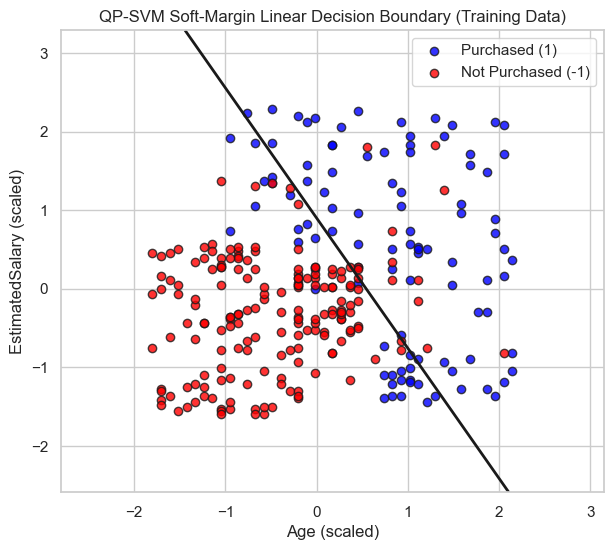

In [ ]:
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = grid_points @ w_star + b_star
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7, 6))
cs = plt.contourf(xx, yy, np.sign(Z), levels=[-np.inf, 0, np.inf],
                  alpha=0.2, cmap="coolwarm")
plt.contour(xx, yy, Z, levels=[0], colors="k", linewidths=2)  # boundary

mask_pos = y_train == 1
mask_neg = y_train == -1

plt.scatter(
    X_train_scaled[mask_pos, 0], X_train_scaled[mask_pos, 1],
    c="blue", edgecolor="k", label="Purchased (1)", alpha=0.8
)
plt.scatter(
    X_train_scaled[mask_neg, 0], X_train_scaled[mask_neg, 1],
    c="red", edgecolor="k", label="Not Purchased (-1)", alpha=0.8
)

plt.xlabel("Age (scaled)")
plt.ylabel("EstimatedSalary (scaled)")
plt.title("QP-SVM Soft-Margin Linear Decision Boundary (Training Data)")
plt.legend()
plt.show()

The visualization of the decision function in the scaled Age–EstimatedSalary plane shows a single straight decision boundary separating most purchased and not-purchased points. Most blue (purchased) samples lie on one side of the line and most red (not purchased) samples on the other, with some points inside the margin or misclassified, which is expected for a soft-margin SVM with C = 1.

## Q10

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from copy import deepcopy

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score

random_state = 42

In [ ]:
df = pd.read_csv("jeeves_tennis.csv")

print("First 5 rows:")
display(df.head())
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nTarget value counts:")
print(df["PlayTennis"].value_counts())

First 5 rows:


,Day_ID,Outlook,Temperature,Humidity,Wind,PlayTennis
0,1,Rain,19.2,High,Strong,No
1,2,Rain,17.4,Low,Weak,Yes
2,3,Sunny,29.9,Normal,Strong,Yes
3,4,Overcast,23.2,Normal,Weak,Yes
4,5,Sunny,29.3,High,Weak,No



Shape: (500, 6)

Columns: ['Day_ID', 'Outlook', 'Temperature', 'Humidity', 'Wind', 'PlayTennis']

Target value counts:
PlayTennis
Yes    290
No     210
Name: count, dtype: int64


In [ ]:
def calculate_entropy_from_counts(counts):
    total = sum(counts)
    if total == 0:
        return 0.0
    probs = [c / total for c in counts if c > 0]
    return -sum(p * np.log2(p) for p in probs)

def calculate_entropy(y):
    counts = Counter(y)
    return calculate_entropy_from_counts(counts.values())

In [ ]:
def calculate_information_gain_discrete(data, feature, target):
    
    y = data[target].values
    base_entropy = calculate_entropy(y)
    
    
    values = data[feature].unique()
    total = len(data)
    cond_entropy = 0.0
    
    for v in values:
        subset = data[data[feature] == v][target].values
        weight = len(subset) / total
        cond_entropy += weight * calculate_entropy(subset)
    
    info_gain = base_entropy - cond_entropy
    return info_gain

day_id_ig = calculate_information_gain_discrete(df, "Day_ID", "PlayTennis")
print("Information Gain for Day_ID:", day_id_ig)

Information Gain for Day_ID: 0.9814538950336537


When I used Day_ID as a normal discrete feature and computed its information gain at the root, I got IG(Day_ID) ≈ 0.9815. This is almost equal to the total entropy of the target, so the algorithm thinks Day_ID is an amazing splitting feature. The reason is that in this synthetic dataset almost every day has a unique ID, so if the tree splits on Day_ID it can basically create (almost) one leaf per example and perfectly memorize the training labels. That makes the leaves very pure, so the conditional entropy becomes very small and IG becomes huge. But this is clearly overfitting and useless for generalization. For a new day with a new Day_ID the tree has never seen that ID before and cannot generalize anything from it. So even though Day_ID has the highest IG, it is not a meaningful pattern and just encodes the sample index. Because of that, I drop Day_ID before building the final decision tree.

In [ ]:
df = df.drop(columns=["Day_ID"])
df.head()

,Outlook,Temperature,Humidity,Wind,PlayTennis
0,Rain,19.2,High,Strong,No
1,Rain,17.4,Low,Weak,Yes
2,Sunny,29.9,Normal,Strong,Yes
3,Overcast,23.2,Normal,Weak,Yes
4,Sunny,29.3,High,Weak,No


In [ ]:
discrete_features = ["Outlook", "Humidity", "Wind"]
target_col = "PlayTennis"

for feat in discrete_features:
    ig = calculate_information_gain_discrete(df, feat, target_col)
    print(f"Information Gain for {feat}: {ig:.4f}")

Information Gain for Outlook: 0.3431
Information Gain for Humidity: 0.0539
Information Gain for Wind: 0.0382


After dropping Day_ID, I computed the information gain at the root for the remaining discrete features and got:
IG(Outlook) = 0.3431
IG(Humidity) = 0.0539
IG(Wind) = 0.0382

So among these, Outlook clearly has the highest information gain. That means splitting on Outlook reduces the entropy of PlayTennis the most at the root, compared to Humidity and Wind. Based on the ID3 criterion, the best attribute for the root node is Outlook.

In [ ]:
def information_gain_for_threshold(data, feature, target, threshold):
    y = data[target].values
    base_entropy = calculate_entropy(y)
    
    left = data[data[feature] <= threshold][target].values
    right = data[data[feature] > threshold][target].values
    
    total = len(data)
    if len(left) == 0 or len(right) == 0:
        return 0.0
    
    cond_entropy = (len(left) / total) * calculate_entropy(left) + \
                   (len(right) / total) * calculate_entropy(right)
    return base_entropy - cond_entropy

In [ ]:
def find_best_split(data, feature, target):
    
    data_sorted = data.sort_values(by=feature).reset_index(drop=True)
    x_vals = data_sorted[feature].values
    y_vals = data_sorted[target].values
    
    
    thresholds = []
    for i in range(len(x_vals) - 1):
        if y_vals[i] != y_vals[i + 1]:
            t = (x_vals[i] + x_vals[i + 1]) / 2.0
            thresholds.append(t)
    
    best_ig = -1.0
    best_t = None
    
    for t in thresholds:
        ig = information_gain_for_threshold(data_sorted, feature, target, t)
        if ig > best_ig:
            best_ig = ig
            best_t = t
    
    return best_t, best_ig

best_temp_threshold, best_temp_ig = find_best_split(df, "Temperature", target_col)
print("Best Temperature threshold:", best_temp_threshold)
print("Information Gain at this threshold:", best_temp_ig)

Best Temperature threshold: 30.05
Information Gain at this threshold: 0.02392309702606632


Temperature is continuous, so I cannot just split by each distinct value like a nominal (categorical) feature. Instead I implemented the usual extension of ID3 for continuous attributes: I sort the data by Temperature, then for every adjacent pair where the class label changes I take the midpoint between the two values as a candidate threshold t. For each candidate t, I compute the information gain:
IG(Temperature, t) = H(Y) − [ (n_≤t / n) H(Y_≤t) + (n_>t / n) H(Y_>t) ],
where Y_≤t and Y_>t are the labels on the two sides of the threshold. Finally, I choose the threshold with the maximum information gain.

On this dataset I got a best threshold t* for Temperature of about 30.05, with information gain about 0.0239. This IG is smaller than the IG of Outlook, so at the root the tree prefers to split on Outlook. Later in the tree, Temperature can still be used with this kind of thresholding.

In [ ]:
class DecisionTreeID3:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree_ = None
        
        self.discrete_features_ = set()
        self.continuous_features_ = set()
    
    def _is_pure(self, y):
        return len(set(y)) == 1
    
    def _majority_class(self, y):
        return Counter(y).most_common(1)[0][0]
    
    def _build_tree(self, data, depth):
        y = data[self.target_col].values
        
        
        if self._is_pure(y) or \
           (self.max_depth is not None and depth >= self.max_depth) or \
           len(data) < self.min_samples_split:
            return {"type": "leaf", "prediction": self._majority_class(y)}
        
        
        best_feature = None
        best_threshold = None
        best_ig = 0.0
        best_splits = None
        
        for feature in self.feature_cols:
            if feature in self.discrete_features_:
                ig = calculate_information_gain_discrete(data, feature, self.target_col)
                if ig > best_ig:
                    
                    splits = {}
                    for v in data[feature].unique():
                        splits[v] = data[data[feature] == v]
                    best_feature = feature
                    best_threshold = None
                    best_ig = ig
                    best_splits = splits
            else:
                
                threshold, ig = find_best_split(data, feature, self.target_col)
                if ig > best_ig and threshold is not None:
                    left = data[data[feature] <= threshold]
                    right = data[data[feature] > threshold]
                    if len(left) > 0 and len(right) > 0:
                        best_feature = feature
                        best_threshold = threshold
                        best_ig = ig
                        best_splits = {"leq": left, "gt": right}
        
        
        if best_feature is None or best_ig <= 0:
            return {"type": "leaf", "prediction": self._majority_class(y)}
        
        
        if best_threshold is None:
            
            node = {
                "type": "node",
                "feature": best_feature,
                "threshold": None,
                "children": {}
            }
            for v, subset in best_splits.items():
                node["children"][v] = self._build_tree(subset, depth + 1)
        else:
            
            node = {
                "type": "node",
                "feature": best_feature,
                "threshold": best_threshold,
                "children": {}
            }
            node["children"]["leq"] = self._build_tree(best_splits["leq"], depth + 1)
            node["children"]["gt"] = self._build_tree(best_splits["gt"], depth + 1)
        
        return node
    
    def fit(self, X, y, discrete_features, continuous_features, target_col_name="PlayTennis"):
        
        data = X.copy()
        data[target_col_name] = y.values
        self.target_col = target_col_name
        self.feature_cols = [c for c in X.columns if c != target_col_name]
        self.discrete_features_ = set(discrete_features)
        self.continuous_features_ = set(continuous_features)
        self.tree_ = self._build_tree(data, depth=0)
        return self
    
    def _predict_one(self, x, node):
        if node["type"] == "leaf":
            return node["prediction"]
        
        feature = node["feature"]
        threshold = node["threshold"]
        
        if threshold is None:
            
            v = x[feature]
            if v in node["children"]:
                return self._predict_one(x, node["children"][v])
            else:
                
                child_preds = []
                for child in node["children"].values():
                    if child["type"] == "leaf":
                        child_preds.append(child["prediction"])
                if child_preds:
                    return Counter(child_preds).most_common(1)[0][0]
                else:
                    return None
        else:
            
            if x[feature] <= threshold:
                return self._predict_one(x, node["children"]["leq"])
            else:
                return self._predict_one(x, node["children"]["gt"])
    
    def predict(self, X):
        preds = []
        for _, row in X.iterrows():
            preds.append(self._predict_one(row, self.tree_))
        return np.array(preds)
    
    
    def _compute_depth_and_leaves(self, node, depth=0):
        if node["type"] == "leaf":
            return depth, 1
        depths = []
        leaves = 0
        for child in node["children"].values():
            d, l = self._compute_depth_and_leaves(child, depth + 1)
            depths.append(d)
            leaves += l
        return (max(depths) if depths else depth), leaves
    
    def get_depth_and_leaves(self):
        return self._compute_depth_and_leaves(self.tree_, depth=0)

In [ ]:

X = df.drop(columns=[target_col])
y = df[target_col]

discrete_features = ["Outlook", "Humidity", "Wind"]
continuous_features = ["Temperature"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state, stratify=y
)

tree = DecisionTreeID3(max_depth=None, min_samples_split=2)
tree.fit(X_train, y_train, discrete_features, continuous_features, target_col_name=target_col)

y_pred = tree.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label="Yes")
rec = recall_score(y_test, y_pred, pos_label="Yes")

print("Test Accuracy:", acc)
print("Test Precision (Yes):", prec)
print("Test Recall (Yes):", rec)

Test Accuracy: 0.95
Test Precision (Yes): 0.9491525423728814
Test Recall (Yes): 0.9655172413793104


I implemented a custom DecisionTreeID3 class that stores the tree as nested Python dictionaries. There are two kinds of nodes: internal nodes and leaves. An internal node has a feature name, an optional threshold (for continuous features like Temperature), and a dictionary of children. A leaf node only stores the predicted class, which is the majority label of the samples reaching that node.

For the discrete features (Outlook, Humidity, Wind) I split into one child for each unique value of the feature. For the continuous feature (Temperature) I use the best threshold found as in part (c) and create two children, one branch for values less than or equal to the threshold and one for values greater than the threshold. The recursion stops when the node is pure (all labels the same), or a maximum depth is reached (if set), or there are not enough samples to split further (min_samples_split).

In [ ]:
depth_clean, leaves_clean = tree.get_depth_and_leaves()
print("Clean tree depth:", depth_clean)
print("Clean tree leaf nodes:", leaves_clean)

Clean tree depth: 13
Clean tree leaf nodes: 42


In [ ]:
def flip_labels(y, frac, random_state=42):
    rng = np.random.RandomState(random_state)
    y_noisy = y.copy().values
    n = len(y_noisy)
    n_flip = int(frac * n)
    idx = rng.choice(n, size=n_flip, replace=False)
    for i in idx:
        y_noisy[i] = "No" if y_noisy[i] == "Yes" else "Yes"
    return pd.Series(y_noisy, index=y.index)

y_train_noisy = flip_labels(y_train, frac=0.1, random_state=random_state)

tree_noisy = DecisionTreeID3(max_depth=None, min_samples_split=2)
tree_noisy.fit(X_train, y_train_noisy, discrete_features, continuous_features, target_col_name=target_col)

depth_noisy, leaves_noisy = tree_noisy.get_depth_and_leaves()
y_pred_noisy = tree_noisy.predict(X_test)

acc_noisy = accuracy_score(y_test, y_pred_noisy)

print("Noisy tree depth:", depth_noisy)
print("Noisy tree leaf nodes:", leaves_noisy)
print("Test Accuracy with noisy training labels:", acc_noisy)

Noisy tree depth: 14
Noisy tree leaf nodes: 112
Test Accuracy with noisy training labels: 0.86


To study overfitting, I injected label noise in the training set. I randomly flipped 10% of the training labels (Yes becomes No and No becomes Yes) using a fixed random seed, and then trained another full DecisionTreeID3 with the same settings (max_depth = None, min_samples_split = 2).



In [ ]:
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_train, y_train, test_size=0.3, random_state=random_state, stratify=y_train
)

base_tree = DecisionTreeID3(max_depth=None, min_samples_split=2)
base_tree.fit(X_subtrain, y_subtrain, discrete_features, continuous_features, target_col_name=target_col)
print("Base tree depth/leaves:", base_tree.get_depth_and_leaves())

Base tree depth/leaves: (8, 25)


In [ ]:
def evaluate_on_validation(tree, X_val, y_val):
    preds = tree.predict(X_val)
    return accuracy_score(y_val, preds)

def clone_tree_structure(node):
    return deepcopy(node)

def prune_node_if_better(node, tree_obj, X_val, y_val):
    
    if node["type"] == "leaf":
        return False  
    
    
    acc_before = evaluate_on_validation(tree_obj, X_val, y_val)
    
    
    backup = deepcopy(node)
    
    
    majority = Counter(y_subtrain).most_common(1)[0][0]
    node.clear()
    node["type"] = "leaf"
    node["prediction"] = majority
    
    acc_after = evaluate_on_validation(tree_obj, X_val, y_val)
    
    if acc_after >= acc_before:
        return True  
    else:
       
        node.clear()
        node.update(backup)
        return False

def prune_tree_recursive(node, tree_obj, X_val, y_val):
    if node["type"] == "leaf":
        return
    
    
    for key in list(node["children"].keys()):
        prune_tree_recursive(node["children"][key], tree_obj, X_val, y_val)
    
    
    prune_node_if_better(node, tree_obj, X_val, y_val)

In [ ]:
def get_tree_size(tree_obj):
    depth, leaves = tree_obj.get_depth_and_leaves()
    return depth, leaves

sizes = []
test_accs = []


pruned_tree = base_tree
depth, leaves = get_tree_size(pruned_tree)
test_acc = accuracy_score(y_test, pruned_tree.predict(X_test))
sizes.append((depth, leaves))
test_accs.append(test_acc)

print("Before pruning -> depth:", depth, "leaves:", leaves, "test acc:", test_acc)


for round_idx in range(1, 6):
    prune_tree_recursive(pruned_tree.tree_, pruned_tree, X_val, y_val)
    depth, leaves = get_tree_size(pruned_tree)
    test_acc = accuracy_score(y_test, pruned_tree.predict(X_test))
    sizes.append((depth, leaves))
    test_accs.append(test_acc)
    print(f"After pruning round {round_idx} -> depth: {depth}, leaves: {leaves}, test acc: {test_acc}")

Before pruning -> depth: 8 leaves: 25 test acc: 0.95
After pruning round 1 -> depth: 3, leaves: 7, test acc: 0.93
After pruning round 2 -> depth: 3, leaves: 7, test acc: 0.93
After pruning round 3 -> depth: 3, leaves: 7, test acc: 0.93
After pruning round 4 -> depth: 3, leaves: 7, test acc: 0.93
After pruning round 5 -> depth: 3, leaves: 7, test acc: 0.93


For pruning I used a simple reduced-error pruning strategy. From the original training set I first created a sub-train set and a validation set (70/30 stratified split). I trained a base ID3 tree on the sub-train part only. Then, on this learned tree, I recursively tried to replace internal nodes by leaves that predict the majority class on the sub-train set. For each candidate pruning, I compared validation accuracy before and after the change and only kept the pruning if the validation accuracy did not decrease.

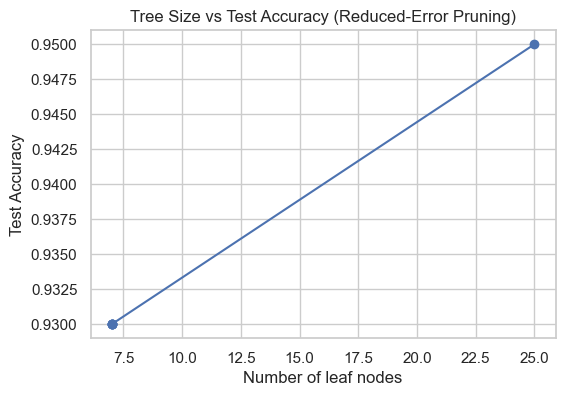

In [ ]:
rounds = list(range(len(sizes)))  
depths = [d for d, l in sizes]
leaves_list = [l for d, l in sizes]

plt.figure(figsize=(6, 4))
plt.plot(leaves_list, test_accs, marker="o")
plt.xlabel("Number of leaf nodes")
plt.ylabel("Test Accuracy")
plt.title("Tree Size vs Test Accuracy (Reduced-Error Pruning)")
plt.grid(True)
plt.show()